In [ ]:
!pip install datasets transformers torch scikit-learn

import pandas as pd
import numpy as np
import torch

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

In [ ]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("clinc_oos", "plus")

train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

train_df = train_df[['text', 'intent']]
test_df = test_df[['text', 'intent']]

print(train_df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plus/train-00000-of-00001.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

plus/validation-00000-of-00001.parquet:   0%|          | 0.00/77.8k [00:00<?, ?B/s]

plus/test-00000-of-00001.parquet:   0%|          | 0.00/136k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15250 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5500 [00:00<?, ? examples/s]

                                                text  intent
0  what expression would i use to say i love you ...      61
1  can you tell me how to say 'i do not speak muc...      61
2  what is the equivalent of, 'life is good' in f...      61
3  tell me how to say, 'it is a beautiful morning...      61
4  if i were mongolian, how would i say that i am...      61


In [ ]:
labels = sorted(train_df['intent'].unique())

label2id = {l:i for i,l in enumerate(labels)}
id2label = {i:l for l,i in label2id.items()}

train_df['label'] = train_df['intent'].map(label2id)
test_df['label'] = test_df['intent'].map(label2id)

In [ ]:
def make_complex(text):
    text = text.lower()

    replacements = {
        "how": "kaise",
        "what": "kya",
        "my": "mera",
        "is": "",
        "the": ""
    }

    for k, v in replacements.items():
        text = text.replace(k, v)

    return text

In [ ]:
test_df['complex_text'] = test_df['text'].apply(make_complex)

In [ ]:
vectorizer = TfidfVectorizer(max_features=10000)

X_train_vec = vectorizer.fit_transform(train_df['text'])
X_test_vec = vectorizer.transform(test_df['text'])

svm_model = LogisticRegression(max_iter=200)
svm_model.fit(X_train_vec, train_df['intent'])

LogisticRegression(max_iter=200)

In [ ]:
y_pred_svm_clean = svm_model.predict(X_test_vec)

print("SVM Clean:",
      accuracy_score(test_df['intent'], y_pred_svm_clean))

SVM Clean: 0.8185454545454546


In [ ]:
X_complex_vec = vectorizer.transform(test_df['complex_text'])

y_pred_svm_complex = svm_model.predict(X_complex_vec)

print("SVM Complex:",
      accuracy_score(test_df['intent'], y_pred_svm_complex))

SVM Complex: 0.7883636363636364


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
class DatasetTorch(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True)
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = DatasetTorch(list(train_df['text']), list(train_df['label']))
test_dataset = DatasetTorch(list(test_df['text']), list(test_df['label']))

In [ ]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(labels)
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    save_strategy="no"
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

Step,Training Loss
500,4.252478
1000,1.965248
1500,0.828001
2000,0.359828
2500,0.157468
3000,0.107286
3500,0.101131
4000,0.068465
4500,0.049525
5000,0.038589


TrainOutput(global_step=5721, training_loss=0.6966583333301327, metrics={'train_runtime': 464.4581, 'train_samples_per_second': 98.502, 'train_steps_per_second': 12.318, 'total_flos': 776881517593500.0, 'train_loss': 0.6966583333301327, 'epoch': 3.0})

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
pred = trainer.predict(test_dataset)

y_pred_bert_clean = np.argmax(pred.predictions, axis=1)

print("BERT Clean:",
      accuracy_score(test_df['label'], y_pred_bert_clean))

BERT Clean: 0.8932727272727272


In [ ]:
complex_dataset = DatasetTorch(
    list(test_df['complex_text']),
    list(test_df['label'])
)

pred_complex = trainer.predict(complex_dataset)

y_pred_bert_complex = np.argmax(pred_complex.predictions, axis=1)

print("BERT Complex:",
      accuracy_score(test_df['label'], y_pred_bert_complex))

BERT Complex: 0.8505454545454545


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer_dl = Tokenizer(num_words=10000)
tokenizer_dl.fit_on_texts(train_df['text'])

X_train_seq = tokenizer_dl.texts_to_sequences(train_df['text'])
X_test_seq = tokenizer_dl.texts_to_sequences(test_df['text'])

X_train_pad = pad_sequences(X_train_seq, maxlen=40)
X_test_pad = pad_sequences(X_test_seq, maxlen=40)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_dl = le.fit_transform(train_df['intent'])
y_test_dl = le.transform(test_df['intent'])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense

model_dl = Sequential([
    Embedding(input_dim=10000, output_dim=128),
    Bidirectional(LSTM(128)),
    Dense(64, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

In [ ]:
model_dl.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
model_dl.fit(
    X_train_pad, y_train_dl,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_pad, y_test_dl)
)

Epoch 1/5
477/477 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.2151 - loss: 3.5164 - val_accuracy: 0.5369 - val_loss: 1.9546
Epoch 2/5
477/477 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7689 - loss: 0.9396 - val_accuracy: 0.7056 - val_loss: 1.2613
Epoch 3/5
477/477 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9090 - loss: 0.3779 - val_accuracy: 0.7000 - val_loss: 1.3190
Epoch 4/5
477/477 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9525 - loss: 0.2051 - val_accuracy: 0.7195 - val_loss: 1.3016
Epoch 5/5
477/477 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9715 - loss: 0.1233 - val_accuracy: 0.7131 - val_loss: 1.4155


In [ ]:
loss, acc = model_dl.evaluate(X_test_pad, y_test_dl)
print("BiLSTM Clean:", acc)

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7131 - loss: 1.4155
BiLSTM Clean: 0.7130908966064453


In [ ]:
X_complex_seq = tokenizer_dl.texts_to_sequences(test_df['complex_text'])
X_complex_pad = pad_sequences(X_complex_seq, maxlen=40)

y_complex_dl = le.transform(test_df['intent'])

loss, acc = model_dl.evaluate(X_complex_pad, y_complex_dl)
print("BiLSTM Complex:", acc)

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6529 - loss: 1.8057
BiLSTM Complex: 0.6529091000556946


In [ ]:
X_complex_vec = vectorizer.transform(test_df['complex_text'])

svm_probs = svm_model.predict_proba(X_complex_vec)
svm_preds = svm_model.classes_[svm_probs.argmax(axis=1)]
svm_confs = svm_probs.max(axis=1)

In [ ]:
bert_preds = []
bert_confs = []

for i in range(0, len(test_df), 32):   # batch size 32
    texts = list(test_df['complex_text'].iloc[i:i+32])

    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True)
    inputs = {k: v.to("cuda") for k, v in inputs.items()}

    with torch.no_grad():
        outputs = bert_model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()

    for p in probs:
        bert_preds.append(id2label[np.argmax(p)])
        bert_confs.append(np.max(p))

In [ ]:
def bilstm_predict(text):
    seq = tokenizer_dl.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=40)

    probs = model_dl.predict(pad, verbose=0)[0]

    pred = le.classes_[probs.argmax()]
    return pred, float(max(probs))

In [ ]:
correct = 0

for i in range(len(test_df)):

    # BERT confidence rule
    if bert_confs[i] > 0.75:
        pred = bert_preds[i]
    else:
        pred = svm_preds[i]

    if pred == test_df['intent'].iloc[i]:
        correct += 1

print("Hybrid Complex:", correct / len(test_df))

Hybrid Complex: 0.8545454545454545


In [ ]:
def hybrid_decision(bert_pred, bert_conf, svm_pred, svm_conf):

    scores = {}

    # weighted confidence
    scores[bert_pred] = scores.get(bert_pred, 0) + (bert_conf * 0.7)
    scores[svm_pred] = scores.get(svm_pred, 0) + (svm_conf * 0.3)

    return max(scores, key=scores.get)

In [ ]:
correct = 0

for i in range(len(test_df)):

    pred = hybrid_decision(
        bert_preds[i], bert_confs[i],
        svm_preds[i], svm_confs[i]
    )

    if pred == test_df['intent'].iloc[i]:
        correct += 1

print("Hybrid Complex:", correct / len(test_df))

Hybrid Complex: 0.8501818181818181


In [ ]:
weights = {
    "bert": 0.5,
    "bilstm": 0.3,
    "svm": 0.2
}

In [ ]:
bilstm_preds = []
bilstm_confs = []

X_complex_seq = tokenizer_dl.texts_to_sequences(test_df['complex_text'])
X_complex_pad = pad_sequences(X_complex_seq, maxlen=40)

# batch prediction
probs = model_dl.predict(X_complex_pad, verbose=0)

for p in probs:
    bilstm_preds.append(le.classes_[np.argmax(p)])
    bilstm_confs.append(float(np.max(p)))

In [ ]:
def hybrid_decision(bert_pred, bert_conf,
                    bilstm_pred, bilstm_conf,
                    svm_pred, svm_conf):

    scores = {}

    # Add weighted scores for each model
    for pred, conf, weight in [
        (bert_pred, bert_conf, weights["bert"]),
        (bilstm_pred, bilstm_conf, weights["bilstm"]),
        (svm_pred, svm_conf, weights["svm"])
    ]:
        if pred not in scores:
            scores[pred] = 0

        scores[pred] += conf * weight

    # Final prediction = max score
    return max(scores, key=scores.get)

In [ ]:
correct = 0

for i in range(len(test_df)):

    pred = hybrid_decision(
        bert_preds[i], bert_confs[i],
        bilstm_preds[i], bilstm_confs[i],
        svm_preds[i], svm_confs[i]
    )

    if pred == test_df['intent'].iloc[i]:
        correct += 1

print("Hybrid Complex:", correct / len(test_df))

Hybrid Complex: 0.8501818181818181


In [ ]:
# Experiment 1 (your dataset)
models = ['SVM', 'BiLSTM', 'BERT', 'Hybrid']
clean_small = [0.98, 0.98, 1.00, None]   # Hybrid optional
complex_small = [0.43, 0.14, 0.37, 0.41]

# Experiment 2 (CLINC150)
clean_large = [0.8185, 0.7227, 0.9009, 0.90]
complex_large = [0.7883, 0.6621, 0.8514, 0.8545]

TypeError: unsupported operand type(s) for +: 'int' and 'NoneType'

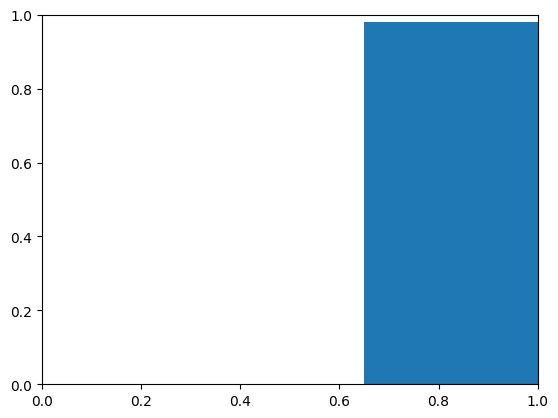

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(models))
width = 0.35

plt.figure()
plt.bar(x - width/2, clean_small, width, label='Clean')
plt.bar(x + width/2, complex_small, width, label='Complex')

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Experiment 1: Clean vs Complex Accuracy")
plt.xticks(x, models)
plt.legend()

plt.show()

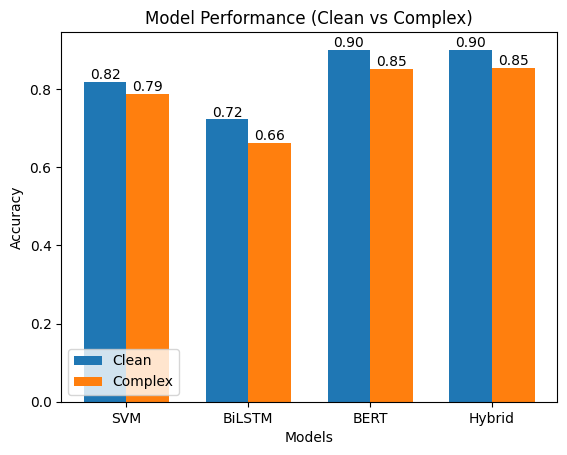

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['SVM', 'BiLSTM', 'BERT', 'Hybrid']

clean = [0.8185, 0.7227, 0.9009, 0.90]
complex_ = [0.7883, 0.6621, 0.8514, 0.8545]

x = np.arange(len(models))
width = 0.35

plt.figure()
bars1 = plt.bar(x - width/2, clean, width, label='Clean')
bars2 = plt.bar(x + width/2, complex_, width, label='Complex')

# 🔥 Add value labels
for bar in bars1 + bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.2f}', ha='center', va='bottom')

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Performance (Clean vs Complex)")
plt.xticks(x, models)
plt.legend()

plt.show()

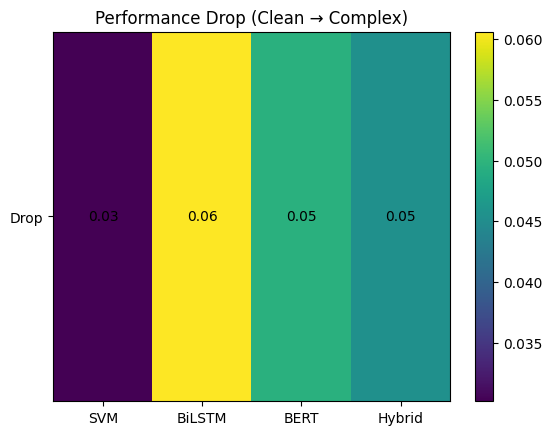

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

drop = [c - d for c, d in zip(clean, complex_)]

plt.figure()
plt.imshow([drop], aspect='auto')

plt.xticks(range(len(models)), models)
plt.yticks([0], ["Drop"])

for i, val in enumerate(drop):
    plt.text(i, 0, f"{val:.2f}", ha='center', va='center')

plt.title("Performance Drop (Clean → Complex)")
plt.colorbar()

plt.show()

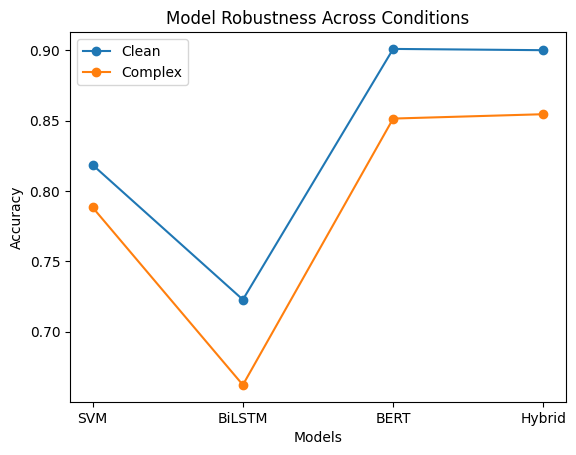

In [ ]:
plt.figure()

plt.plot(models, clean, marker='o', label='Clean')
plt.plot(models, complex_, marker='o', label='Complex')

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Robustness Across Conditions")
plt.legend()

plt.show()

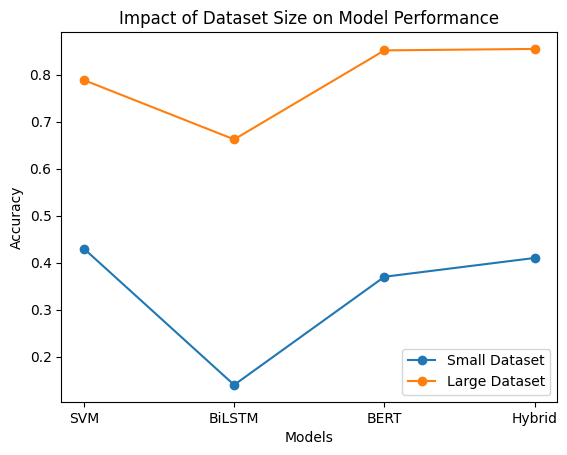

In [ ]:
small_complex = [0.43, 0.14, 0.37, 0.41]
large_complex = [0.7883, 0.6621, 0.8514, 0.8545]

plt.figure()

plt.plot(models, small_complex, marker='o', label='Small Dataset')
plt.plot(models, large_complex, marker='o', label='Large Dataset')

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Impact of Dataset Size on Model Performance")
plt.legend()

plt.show()

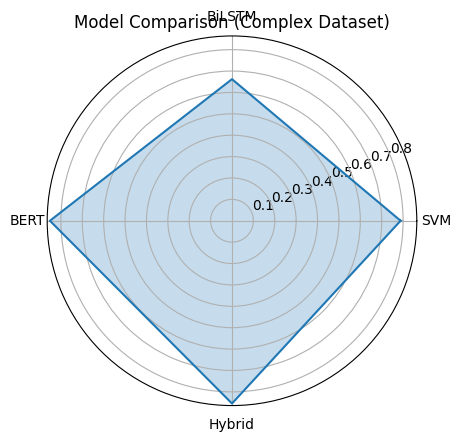

In [ ]:
import numpy as np

labels = np.array(models)
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

values = np.array(complex_)
values = np.concatenate((values, [values[0]]))
angles = np.concatenate((angles, [angles[0]]))

plt.figure()
ax = plt.subplot(111, polar=True)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)

ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)

plt.title("Model Comparison (Complex Dataset)")
plt.show()

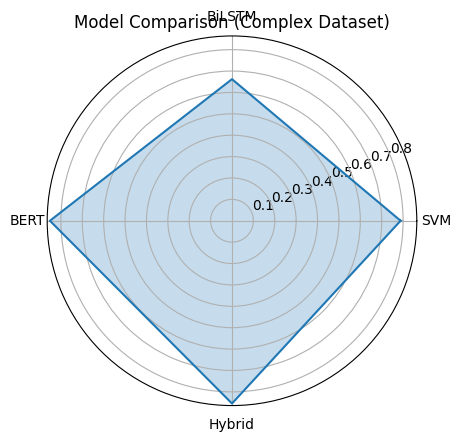

In [ ]:
import numpy as np

labels = np.array(models)
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

values = np.array(complex_)
values = np.concatenate((values, [values[0]]))
angles = np.concatenate((angles, [angles[0]]))

plt.figure()
ax = plt.subplot(111, polar=True)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)

ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)

plt.title("Model Comparison (Complex Dataset)")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Experiment 1 (Small dataset)
models_small = ['SVM', 'BiLSTM', 'BERT', 'Hybrid']
clean_small = [0.98, 0.98, 1.00, None]   # Hybrid clean not available
complex_small = [0.43, 0.14, 0.37, 0.41]

# Experiment 2 (Large dataset - CLINC150)
models_large = ['SVM', 'BiLSTM', 'BERT', 'Hybrid']
clean_large = [0.8185, 0.7227, 0.9009, 0.90]
complex_large = [0.7883, 0.6621, 0.8514, 0.8545]

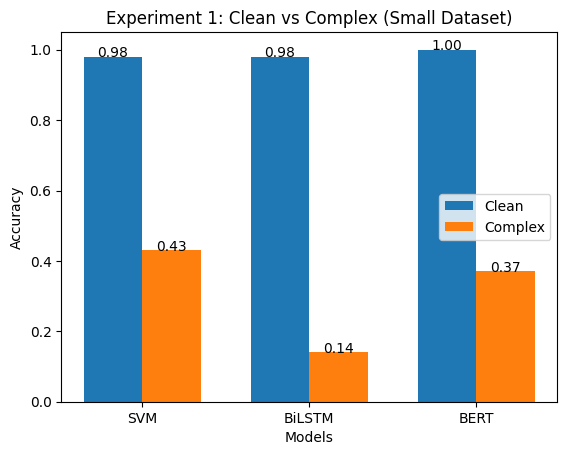

In [ ]:
models_small_clean = ['SVM', 'BiLSTM', 'BERT']
clean_small_clean = [0.98, 0.98, 1.00]
complex_small_clean = [0.43, 0.14, 0.37]

x = np.arange(len(models_small_clean))
width = 0.35

plt.figure()

bars1 = plt.bar(x - width/2, clean_small_clean, width, label='Clean')
bars2 = plt.bar(x + width/2, complex_small_clean, width, label='Complex')

# Value labels
for bar in bars1 + bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.2f}", ha='center')

plt.xticks(x, models_small_clean)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Experiment 1: Clean vs Complex (Small Dataset)")
plt.legend()

plt.show()

In [ ]:
plt.figure()

bars = plt.bar(models_small, complex_small)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.2f}", ha='center')

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Experiment 1: Complex Dataset Performance")

plt.show()

NameError: name 'plt' is not defined

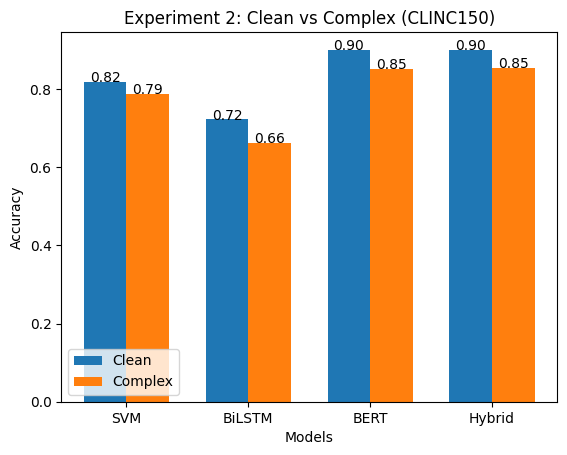

In [ ]:
x = np.arange(len(models_large))
width = 0.35

plt.figure()

bars1 = plt.bar(x - width/2, clean_large, width, label='Clean')
bars2 = plt.bar(x + width/2, complex_large, width, label='Complex')

for bar in bars1 + bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.2f}", ha='center')

plt.xticks(x, models_large)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Experiment 2: Clean vs Complex (CLINC150)")
plt.legend()

plt.show()

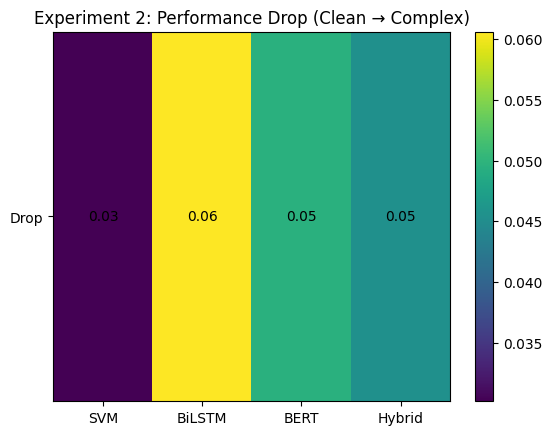

In [ ]:
drop_large = [c - d for c, d in zip(clean_large, complex_large)]

plt.figure()
plt.imshow([drop_large], aspect='auto')

plt.xticks(range(len(models_large)), models_large)
plt.yticks([0], ["Drop"])

for i, val in enumerate(drop_large):
    plt.text(i, 0, f"{val:.2f}", ha='center', va='center')

plt.title("Experiment 2: Performance Drop (Clean → Complex)")
plt.colorbar()

plt.show()

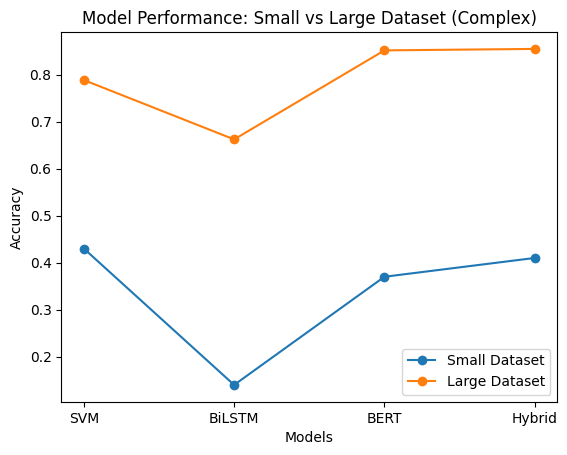

In [ ]:
plt.figure()

plt.plot(models_large, complex_small, marker='o', label='Small Dataset')
plt.plot(models_large, complex_large, marker='o', label='Large Dataset')

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Performance: Small vs Large Dataset (Complex)")
plt.legend()

plt.show()

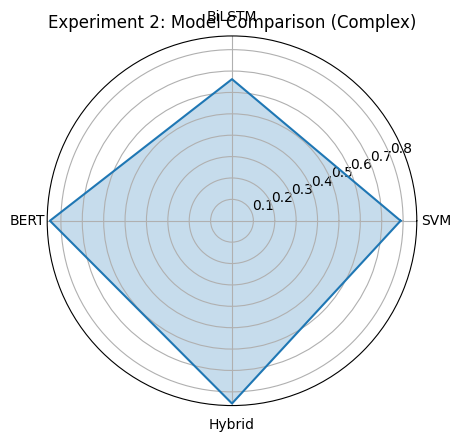

In [ ]:
labels = np.array(models_large)
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

values = np.array(complex_large)
values = np.concatenate((values, [values[0]]))
angles = np.concatenate((angles, [angles[0]]))

plt.figure()
ax = plt.subplot(111, polar=True)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)

ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)

plt.title("Experiment 2: Model Comparison (Complex)")
plt.show()